# MS COCO — classification multi-label : analyse des resultats

Notebook de rendu. Il n'implemente aucune logique : tout vient des modules de
`src/coco_mlc/` et des resultats produits par les scripts de `scripts/`. Son
role est de **presenter et d'analyser**.

Pour regenerer les resultats de zero :

```bash
python3 scripts/explore_dataset.py
python3 scripts/cache_features.py --model mobilenet_v3_large
python3 scripts/cache_features.py --model resnet18
python3 scripts/train_head.py --model mobilenet_v3_large --sweep
python3 scripts/tune_thresholds.py --checkpoint outputs/head_<...>.pth --save
python3 scripts/predict.py --checkpoint outputs/head_<...>.pth --submit-copy
```

Plan :
1. le probleme et la metrique
2. les donnees
3. la contrainte de calcul et la strategie
4. etude comparative
5. calibration des seuils
6. analyse par classe
7. soumission

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from coco_mlc.config import CLASSES, NUM_CLASSES, PATHS
from coco_mlc.data import get_split, load_label_matrix
from coco_mlc.engine import load_checkpoint
from coco_mlc.features import available_caches, load_cache, load_train_cache
from coco_mlc.inference import build_head_module, score_features
from coco_mlc.metrics import all_metrics, metric_class_weights
from coco_mlc.thresholds import tune_global_threshold, tune_per_class_thresholds
from coco_mlc.utils import environment_summary

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
print(environment_summary())

/home/cytech/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


{'python': '3.12.11', 'torch': '2.7.0+cpu', 'torchvision': '0.22.0+cpu', 'cuda': 'cpu', 'threads': '4', 'git': '0df747a'}


## 1. Le probleme, et la metrique qui le definit

Chaque image peut contenir plusieurs des 80 categories. La difference avec la
classification mono-label du TP CIFAR-10 porte sur trois points :

| | Mono-label (CIFAR-10) | Multi-label (MS COCO) |
| --- | --- | --- |
| Cible | un entier | vecteur multi-hot de 80 valeurs |
| Cout | `CrossEntropyLoss` (softmax sur les classes) | `BCEWithLogitsLoss` (sigmoide par classe) |
| Prediction | `argmax` | seuillage classe par classe |

Mais le point determinant n'est pas la : c'est **la ponderation de la metrique
d'evaluation**. La cellule suivante la rend visible.

In [2]:
ids, Y = load_label_matrix()
freqs = Y.sum(axis=0)
weights = metric_class_weights(freqs).numpy()

stats = pd.DataFrame({
    "classe": CLASSES,
    "positifs": freqs,
    "poids_metrique_pct": 100 * weights,
}).sort_values("poids_metrique_pct", ascending=False)

cumul = stats.poids_metrique_pct.cumsum()
print(f"Images annotees            : {len(Y):,}")
print(f"Classes par image (moyenne): {Y.sum(axis=1).mean():.2f}")
print(f"Rapport de frequence max/min: {freqs.max() / freqs.min():.0f}x")
print(f"Poids des 2 classes les plus rares : {cumul.iloc[1]:.1f} % du score")
print(f"Poids des 10 classes les plus rares: {cumul.iloc[9]:.1f} % du score")
print(f"Poids des 40 classes les plus frequentes: {100 - cumul.iloc[39]:.1f} % du score")
print()
display(pd.concat([stats.head(6), stats.tail(3)]))

Images annotees            : 65,000
Classes par image (moyenne): 2.93
Rapport de frequence max/min: 348x
Poids des 2 classes les plus rares : 25.5 % du score
Poids des 10 classes les plus rares: 43.8 % du score
Poids des 40 classes les plus frequentes: 22.0 % du score



,classe,positifs,poids_metrique_pct
78,hair drier,102,13.638188
70,toaster,117,11.889703
12,parking meter,396,3.512866
21,bear,516,2.695921
76,scissors,555,2.506478
79,toothbrush,561,2.479670
2,car,6811,0.204242
56,chair,7043,0.197515
0,person,35494,0.039192


**Lecture.** La metrique du serveur pondere la precision et le rappel de chaque
classe par `1/frequence`. `hair drier` (102 positifs) pese donc 350 fois plus
que `person` (35 494 positifs). Les dix classes les plus rares font 44 % du
score, les quarante plus frequentes seulement 22 %.

Trois consequences, qui structurent tout le travail :

1. optimiser l'accuracy ou le micro-F1 est contre-productif ;
2. le rappel sur les classes rares est le levier principal ;
3. un seuil unique a 0,5 est tres sous-optimal.

Notre implementation de la metrique est verifiee contre celle du sujet par
`tests/test_metrics_parity.py` (ecart < 1e-5 sur quatre configurations).

In [3]:
!cd {REPO} && python3 tests/test_metrics_parity.py

OK  parite avec validation_loop du sujet (4 configurations)
OK  cas degeneres (support nul, precision nulle) sans nan ni inf
OK  compteurs et tableau de seuils coherents


OK  calibration par classe : F1 0.7585 -> 0.9279
OK  garde-fou : au moins une classe predite par image

Tous les tests passent.


## 2. Les donnees

Figures produites par `scripts/explore_dataset.py`.

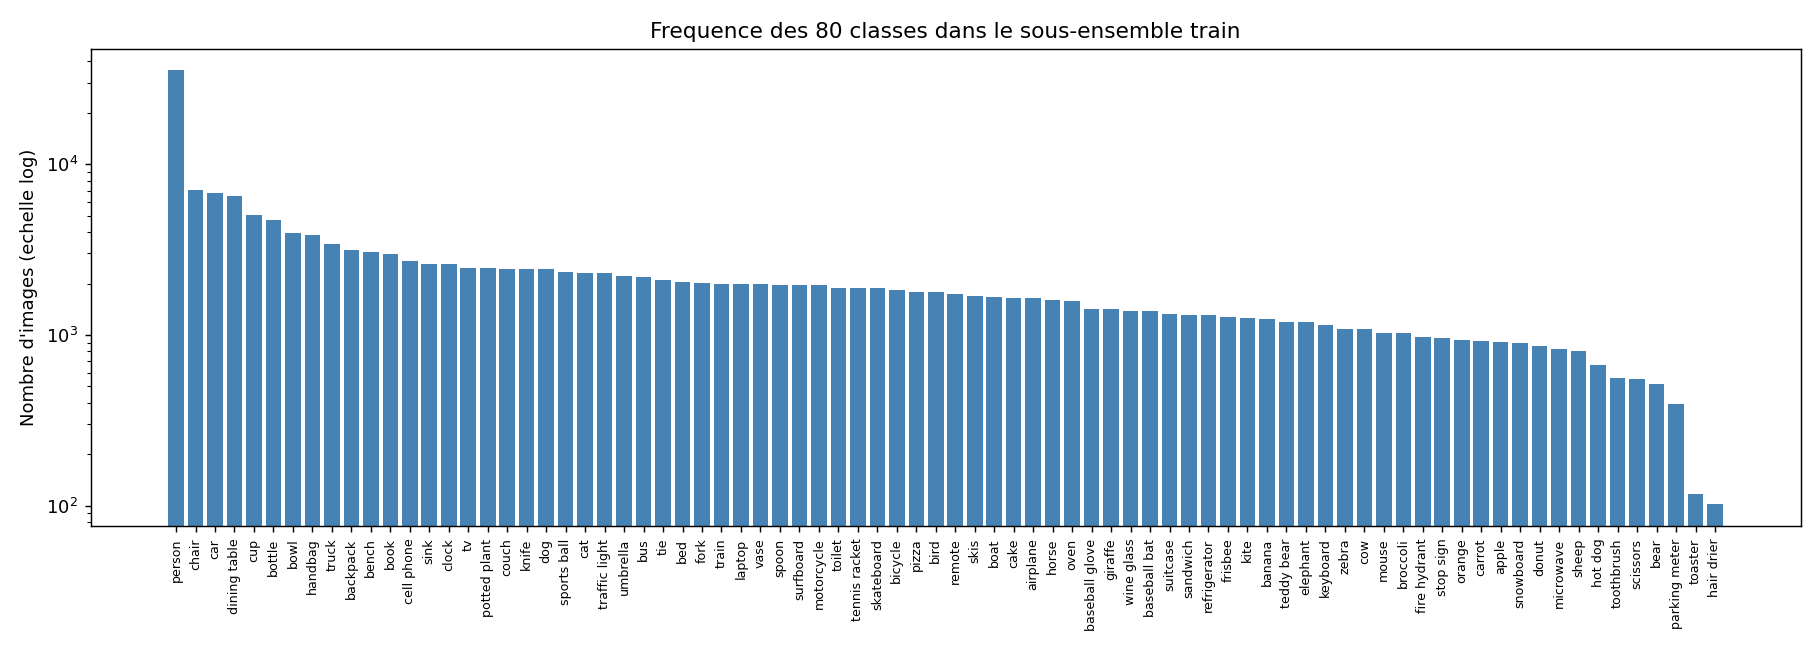

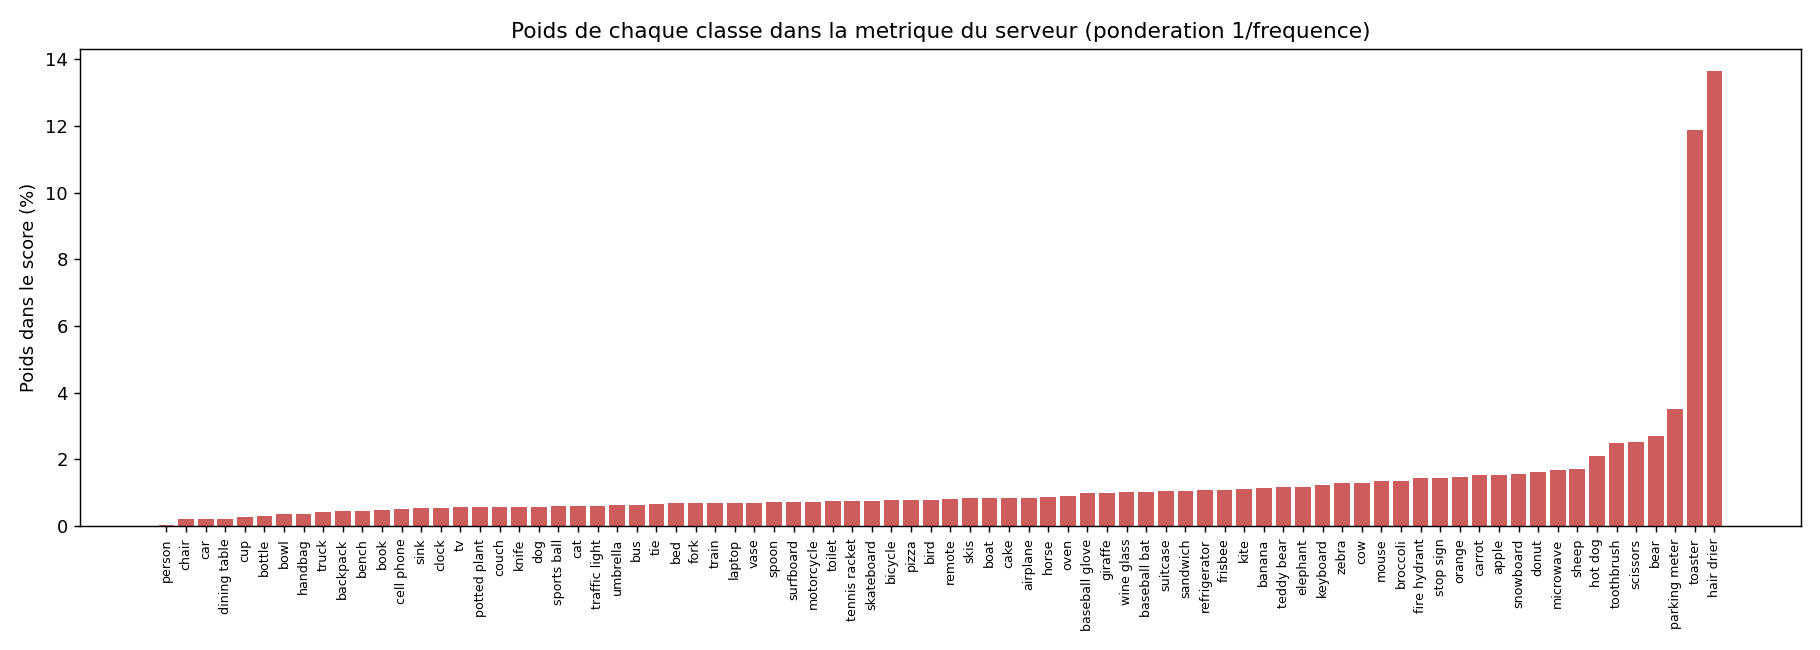

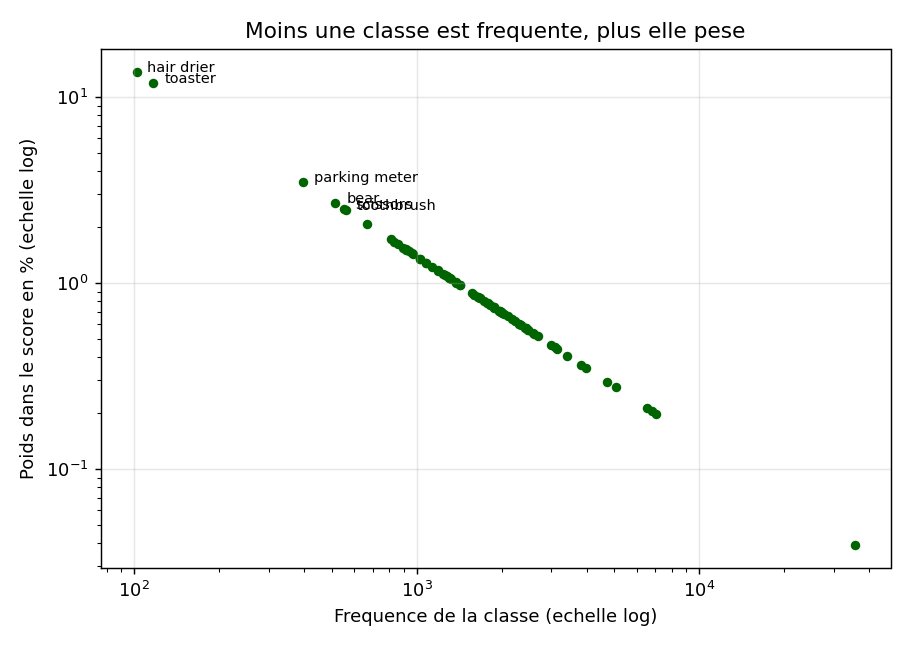

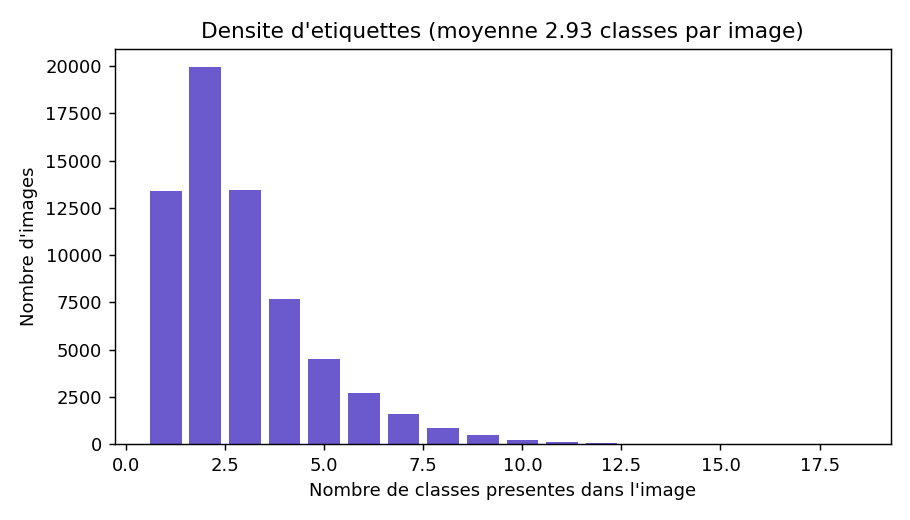

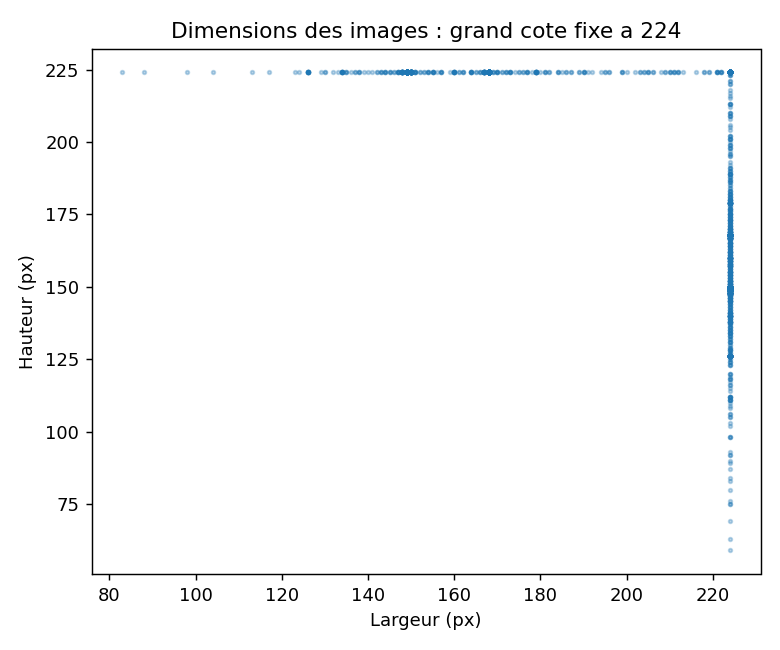

In [4]:
from IPython.display import Image as ShowImage
from IPython.display import display

figures = PATHS.outputs / "figures"
for name in ["class_frequency.png", "metric_weights.png", "weight_vs_frequency.png",
             "labels_per_image.png", "image_dimensions.png"]:
    path = figures / name
    if path.exists():
        display(ShowImage(filename=str(path), width=900))
    else:
        print(f"manquant : {path} (lancer scripts/explore_dataset.py)")

### Decoupage train / validation

Le sujet suggere `random_split`. Avec seulement 102 positifs pour `hair drier`,
un tirage aleatoire donne une metrique de validation bruitee sur les classes qui
pesent le plus. Nous utilisons une stratification iterative multi-label.

In [5]:
comparaison = []
for strategy in ("stratified", "random"):
    _, val_idx = get_split(Y, 0.2, 42, strategy=strategy)
    support = Y[val_idx].sum(axis=0)
    attendu = 0.2 * freqs
    comparaison.append({
        "strategie": strategy,
        "images_validation": len(val_idx),
        "erreur_relative_pct": 100 * np.abs(support - attendu).sum() / attendu.sum(),
        "support_min": support.min(),
        "support_hair_drier": support[CLASSES.index("hair drier")],
    })
pd.DataFrame(comparaison)

,strategie,images_validation,erreur_relative_pct,support_min,support_hair_drier
0,stratified,12953,0.104631,20,20
1,random,13000,3.446517,18,18


## 3. La contrainte de calcul, et la strategie qui en decoule

La machine de developpement n'a pas de GPU. Debits mesures par
`scripts/benchmark_speed.py` :

In [6]:
bench_path = PATHS.outputs / "benchmark_speed.csv"
if bench_path.exists():
    display(pd.read_csv(bench_path))
else:
    print("lancer scripts/benchmark_speed.py")

,model,params_M,gflops_doc,imagenet_acc1,forward_img_per_s,train_img_per_s,cache_features_70k,one_epoch_52k
0,mobilenet_v3_small,1.6,0.06,67.67,270.9,70.8,4m18s,12m14s
1,mobilenet_v3_large,4.3,0.22,75.27,77.5,22.9,15m03s,37m54s
2,resnet18,11.2,1.81,69.76,49.9,17.4,23m22s,49m48s
3,resnet50,23.7,4.09,80.86,17.2,5.6,1h07m56s,2h33m36s


Une epoque de fine-tuning ResNet18 coute environ 50 minutes en CPU, et 2 h 34
pour ResNet50 : une etude comparative serait impossible. D'ou deux programmes
complementaires.

**Extraction de features.** Le backbone gele produit des sorties independantes
de l'apprentissage : un seul passage forward suffit, puis chaque experience de
tete prend quelques secondes. C'est ce qui rend l'etude comparative realisable
sans GPU.

**Fine-tuning.** Met tout le reseau a jour, plus performant, reserve au GPU
Colab (`notebooks/colab_finetune.ipynb`), avec exactement le meme code.

In [7]:
for cache in available_caches():
    data = load_cache(cache / "train.npz")
    taille = sum(p.stat().st_size for p in cache.glob("*.npz")) / 1e6
    print(f"{cache.name:34s} features {data['features'].shape} "
          f"{data['features'].dtype}  {taille:.0f} Mo sur disque")

mobilenet_v3_large_224_pad         features (65000, 1280) float16  188 Mo sur disque


## 4. Etude comparative

Registre de toutes les experiences : `outputs/experiments.csv`. Dans le `--sweep`
de `train_head.py`, **une seule variable change a la fois** par rapport a la
baseline (tete lineaire + BCE), condition pour que les ecarts soient
interpretables.

In [8]:
experiments = pd.read_csv(PATHS.outputs / "experiments.csv")
colonnes = ["backbone", "strategy", "head", "loss", "val_f1", "val_precision",
            "val_recall", "val_mAP", "val_macro_f1", "val_micro_f1",
            "best_epoch", "seconds"]
table = experiments[[c for c in colonnes if c in experiments]].sort_values(
    "val_f1", ascending=False
)
table

,backbone,strategy,head,loss,val_f1,val_precision,val_recall,val_mAP,val_macro_f1,val_micro_f1,best_epoch,seconds
4,mobilenet_v3_large,feature_extraction,mlp,bce,0.5614,0.5539,0.5692,0.6549,0.5875,0.6166,3,252.1
5,mobilenet_v3_large,feature_extraction,mlp,bce_pos_weight,0.5512,0.5516,0.5509,0.6287,0.5830,0.6151,22,253.6
6,mobilenet_v3_large,feature_extraction,mlp,asl,0.5407,0.5508,0.5309,0.6405,0.6056,0.6500,13,264.4
0,mobilenet_v3_large,feature_extraction,linear,bce,0.5317,0.6681,0.4416,0.6413,0.6073,0.6638,5,36.2
1,mobilenet_v3_large,feature_extraction,linear,bce_pos_weight,0.5176,0.6128,0.4480,0.5815,0.5681,0.5853,2,35.7
2,mobilenet_v3_large,feature_extraction,linear,focal,0.4829,0.5042,0.4633,0.6160,0.5886,0.6457,7,41.4
3,mobilenet_v3_large,feature_extraction,linear,asl,0.4804,0.5576,0.4220,0.6054,0.5746,0.6301,11,45.1
7,mobilenet_v3_large,feature_extraction,linear,bce,0.4574,0.5049,0.4180,0.6241,0.5879,0.6575,40,38.8


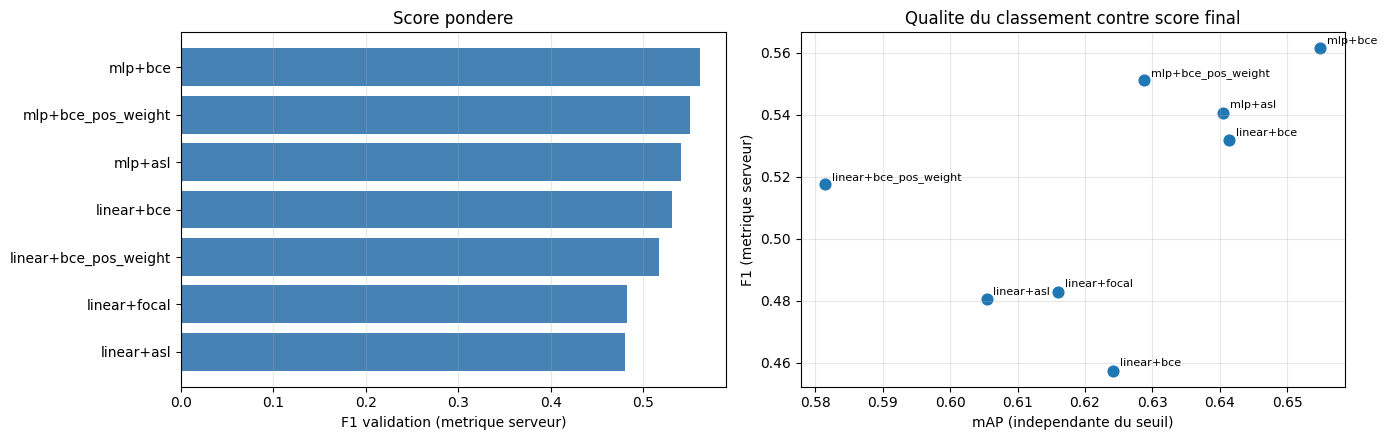

In [9]:
# F1 (dependant du seuil) contre mAP (independante du seuil) : les deux
# grandeurs ne classent pas forcement les configurations dans le meme ordre.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

def etiquette(r):
    nom = f"{r.get('head', '?')}+{r['loss']}"
    return nom if r.get("prior_bias", True) else nom + " (sans biais prior)"

etiquettes = table.apply(etiquette, axis=1)
axes[0].barh(etiquettes, table.val_f1, color="steelblue")
axes[0].invert_yaxis()
axes[0].set_xlabel("F1 validation (metrique serveur)")
axes[0].set_title("Score pondere")
axes[0].grid(axis="x", alpha=0.3)

axes[1].scatter(table.val_mAP, table.val_f1, s=60)
for _, r in table.iterrows():
    axes[1].annotate(etiquette(r), (r.val_mAP, r.val_f1),
                     fontsize=8, xytext=(5, 3), textcoords="offset points")
axes[1].set_xlabel("mAP (independante du seuil)")
axes[1].set_ylabel("F1 (metrique serveur)")
axes[1].set_title("Qualite du classement contre score final")
axes[1].grid(alpha=0.3)

fig.tight_layout()

L'ecart entre les deux courbes de F1 mesure directement l'enjeu de la calibration.


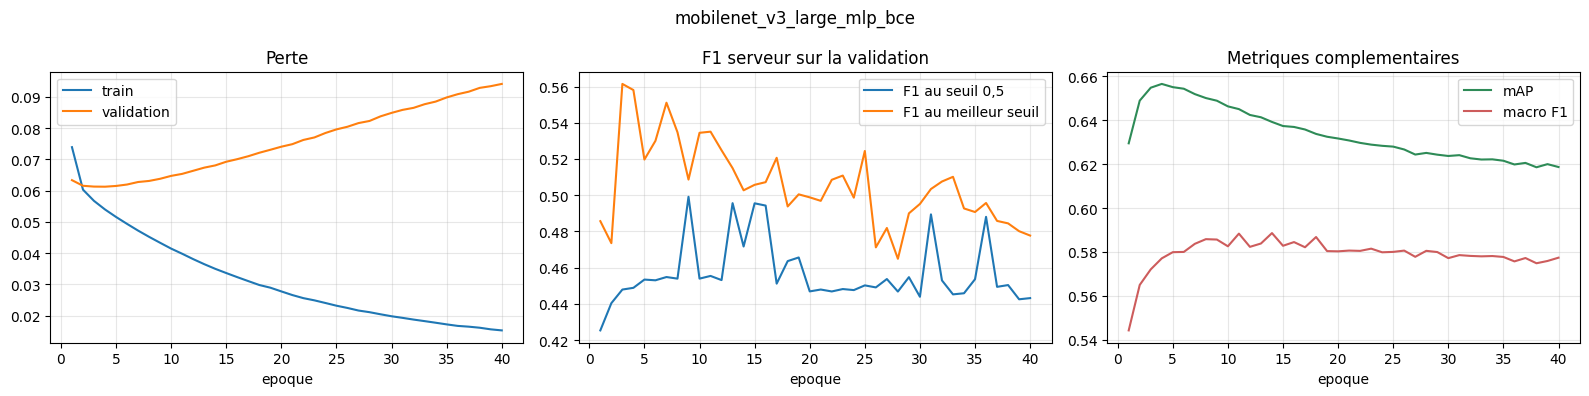

In [10]:
# Courbes d'apprentissage de la meilleure configuration.
meilleure = table.iloc[0]
nom = f"{meilleure['backbone']}_{meilleure.get('head', 'linear')}_{meilleure['loss']}"
chemin = PATHS.outputs / f"history_{nom}.csv"

if chemin.exists():
    history = pd.read_csv(chemin)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history.epoch, history.train_loss, label="train")
    axes[0].plot(history.epoch, history.val_loss, label="validation")
    axes[0].set_title("Perte")
    axes[0].set_xlabel("epoque")
    axes[0].legend()

    axes[1].plot(history.epoch, history["val_f1_th0.5"], label="F1 au seuil 0,5")
    axes[1].plot(history.epoch, history.val_f1_tuned, label="F1 au meilleur seuil")
    axes[1].set_title("F1 serveur sur la validation")
    axes[1].set_xlabel("epoque")
    axes[1].legend()

    axes[2].plot(history.epoch, history.val_mAP, label="mAP", color="seagreen")
    axes[2].plot(history.epoch, history.val_macro_f1, label="macro F1", color="indianred")
    axes[2].set_title("Metriques complementaires")
    axes[2].set_xlabel("epoque")
    axes[2].legend()

    for ax in axes:
        ax.grid(alpha=0.3)
    fig.suptitle(nom)
    fig.tight_layout()
    print("L'ecart entre les deux courbes de F1 mesure directement l'enjeu de la calibration.")
else:
    print(f"manquant : {chemin}")

## 5. Calibration des seuils

Puisque les classes rares dominent le score, abaisser leur seuil gagne beaucoup
de rappel la ou cela compte, pour un cout de precision reparti sur l'ensemble.
Les seuils sont optimises par montee de coordonnees sur **exactement** la
metrique du serveur, et **uniquement sur la validation**.

In [11]:
# Rechargement du meilleur modele et de ses scores de validation.
checkpoint_path = PATHS.outputs / f"head_{nom}.pth"
checkpoint = load_checkpoint(checkpoint_path)

cache = load_train_cache(checkpoint["backbone"], checkpoint["image_size"],
                         checkpoint["resize_mode"])
_, val_idx = get_split(cache["labels"], checkpoint["split"]["val_fraction"],
                       checkpoint["seed"], strategy=checkpoint["split"]["strategy"])

tete = build_head_module(checkpoint)
scores = score_features(tete, cache["features"][val_idx])
cibles = torch.from_numpy(cache["labels"][val_idx].astype(np.float32))
print(f"{len(scores):,} images de validation, scores de forme {tuple(scores.shape)}")

12,953 images de validation, scores de forme (12953, 80)


,strategie,F1,gain_vs_0.5_pct
0,"seuil 0,5",0.447892,0.000000
1,seuil unique optimal (0.14),0.561437,25.351196
2,un seuil par classe,0.614508,37.200085


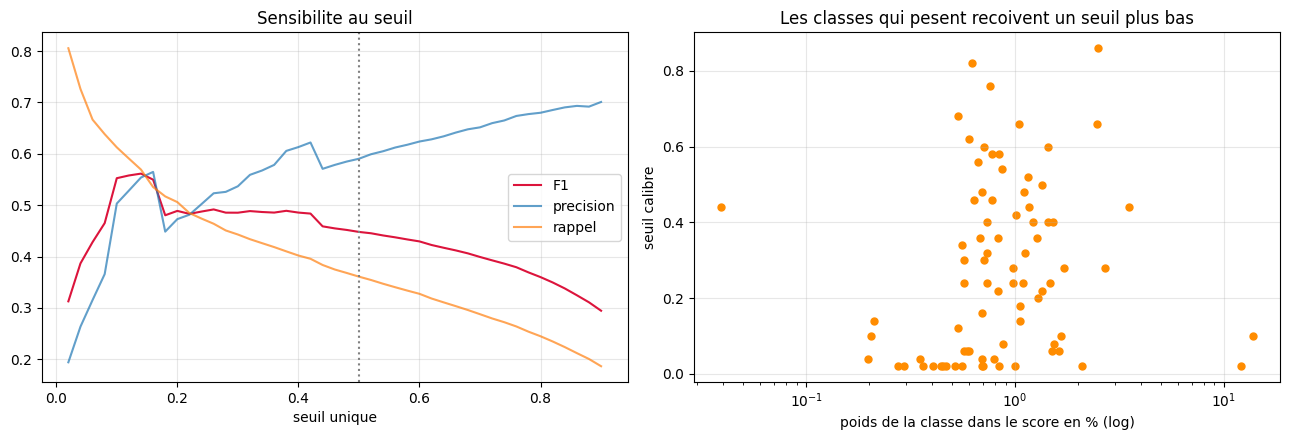

In [12]:
f1_defaut = all_metrics(scores, cibles, thresholds=0.5)["f1"]
seuil_global, f1_global, courbe = tune_global_threshold(scores, cibles)
seuils_classe, f1_classe, _ = tune_per_class_thresholds(
    scores, cibles, init_threshold=seuil_global, verbose=False
)

resume = pd.DataFrame([
    {"strategie": "seuil 0,5", "F1": f1_defaut},
    {"strategie": f"seuil unique optimal ({seuil_global:.2f})", "F1": f1_global},
    {"strategie": "un seuil par classe", "F1": f1_classe},
])
resume["gain_vs_0.5_pct"] = 100 * (resume.F1 - f1_defaut) / f1_defaut
display(resume)

courbe_df = pd.DataFrame(courbe)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(courbe_df.threshold, courbe_df.f1, label="F1", color="crimson")
axes[0].plot(courbe_df.threshold, courbe_df.precision, label="precision", alpha=0.7)
axes[0].plot(courbe_df.threshold, courbe_df.recall, label="rappel", alpha=0.7)
axes[0].axvline(0.5, ls=":", color="gray")
axes[0].set_xlabel("seuil unique")
axes[0].set_title("Sensibilite au seuil")
axes[0].legend()
axes[0].grid(alpha=0.3)

poids_val = metric_class_weights(cibles.sum(axis=0)).numpy()
axes[1].scatter(100 * poids_val, seuils_classe.numpy(), s=25, color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("poids de la classe dans le score en % (log)")
axes[1].set_ylabel("seuil calibre")
axes[1].set_title("Les classes qui pesent recoivent un seuil plus bas")
axes[1].grid(alpha=0.3)
fig.tight_layout()

### La calibration sur-apprend-elle la validation ?

Regler 80 seuils sur la validation peut la sur-apprendre, surtout pour les
classes a faible support. On le quantifie : calibration sur une moitie,
evaluation sur l'autre.

In [13]:
g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(scores), generator=g)
moitie = len(scores) // 2
calib, test_interne = perm[:moitie], perm[moitie:]

seuil_g, _, _ = tune_global_threshold(scores[calib], cibles[calib])
seuils_c, _, _ = tune_per_class_thresholds(scores[calib], cibles[calib], verbose=False)

pd.DataFrame([
    {"seuils": "0,5",
     "F1 sur la moitie non utilisee": all_metrics(scores[test_interne], cibles[test_interne], 0.5)["f1"]},
    {"seuils": "unique, calibre",
     "F1 sur la moitie non utilisee": all_metrics(scores[test_interne], cibles[test_interne], seuil_g)["f1"]},
    {"seuils": "par classe, calibres",
     "F1 sur la moitie non utilisee": all_metrics(scores[test_interne], cibles[test_interne], seuils_c)["f1"]},
])

,seuils,F1 sur la moitie non utilisee
0,"0,5",0.448207
1,"unique, calibre",0.578241
2,"par classe, calibres",0.612789


## 6. Analyse par classe

Ou le modele gagne et perd du score, en tenant compte des poids.

In [14]:
_, par_classe = all_metrics(scores, cibles, thresholds=seuils_classe, class_metrics=True)

detail = pd.DataFrame({
    "classe": CLASSES,
    "support_val": [c["support"] for c in par_classe],
    "poids_pct": 100 * poids_val,
    "seuil": seuils_classe.numpy(),
    "precision": [c["precision"] for c in par_classe],
    "rappel": [c["recall"] for c in par_classe],
    "f1": [c["f1"] for c in par_classe],
})
# Contribution reelle au score : un F1 de classe eleve sur une classe sans poids
# ne rapporte presque rien.
detail["contribution_pct"] = detail.poids_pct * detail.f1 / 100

print("Les 15 classes qui pesent le plus :")
display(detail.sort_values("poids_pct", ascending=False).head(15).round(3))

print("\nLes 10 classes les plus couteuses (poids eleve, F1 faible) :")
detail["perte_pct"] = detail.poids_pct * (1 - detail.f1)
display(detail.sort_values("perte_pct", ascending=False).head(10).round(3))

Les 15 classes qui pesent le plus :


,classe,support_val,poids_pct,seuil,precision,rappel,f1,contribution_pct
78,hair drier,20,13.840,0.10,1.000,0.100,0.182,0.025
70,toaster,23,12.035,0.02,0.065,0.652,0.118,0.014
12,parking meter,79,3.504,0.44,0.885,0.291,0.438,0.015
21,bear,103,2.687,0.28,0.898,0.854,0.876,0.024
76,scissors,111,2.494,0.86,1.000,0.135,0.238,0.006
79,toothbrush,112,2.471,0.66,1.000,0.107,0.194,0.005
52,hot dog,133,2.081,0.02,0.148,0.865,0.253,0.005
18,sheep,162,1.709,0.28,0.837,0.759,0.796,0.014
68,microwave,166,1.667,0.10,0.353,0.723,0.474,0.008
54,donut,171,1.619,0.06,0.306,0.743,0.433,0.007



Les 10 classes les plus couteuses (poids eleve, F1 faible) :


,classe,support_val,poids_pct,seuil,precision,rappel,f1,contribution_pct,perte_pct
78,hair drier,20,13.840,0.10,1.000,0.100,0.182,0.025,11.323
70,toaster,23,12.035,0.02,0.065,0.652,0.118,0.014,10.619
79,toothbrush,112,2.471,0.66,1.000,0.107,0.194,0.005,1.993
12,parking meter,79,3.504,0.44,0.885,0.291,0.438,0.015,1.969
76,scissors,111,2.494,0.86,1.000,0.135,0.238,0.006,1.900
52,hot dog,133,2.081,0.02,0.148,0.865,0.253,0.005,1.555
51,carrot,184,1.504,0.06,0.240,0.853,0.374,0.006,0.941
54,donut,171,1.619,0.06,0.306,0.743,0.433,0.007,0.917
68,microwave,166,1.667,0.10,0.353,0.723,0.474,0.008,0.877
40,wine glass,276,1.003,0.02,0.118,0.924,0.210,0.002,0.792


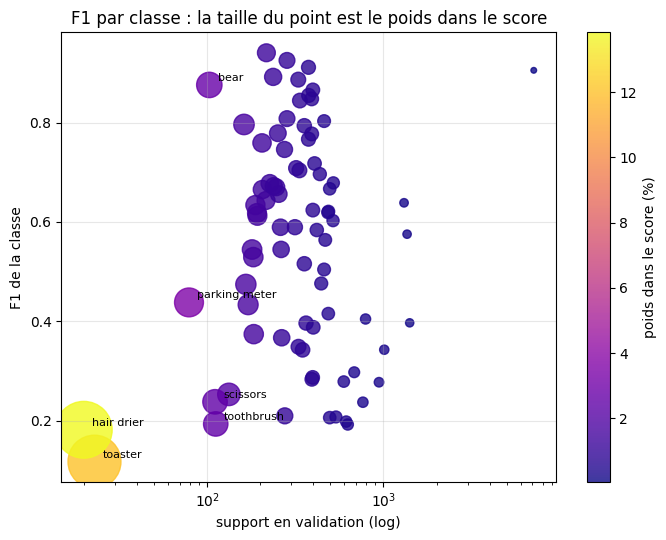

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.5))
nuage = ax.scatter(detail.support_val, detail.f1, s=120 * detail.poids_pct + 12,
                   c=detail.poids_pct, cmap="plasma", alpha=0.8)
for _, r in detail.sort_values("poids_pct", ascending=False).head(6).iterrows():
    ax.annotate(r.classe, (r.support_val, r.f1), fontsize=8,
                xytext=(6, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("support en validation (log)")
ax.set_ylabel("F1 de la classe")
ax.set_title("F1 par classe : la taille du point est le poids dans le score")
ax.grid(alpha=0.3)
fig.colorbar(nuage, label="poids dans le score (%)")
fig.tight_layout()

## 7. Soumission

`scripts/predict.py` ecrit le JSON et le verifie avant de le declarer pret :
4 952 entrees, identifiants a 12 chiffres, indices entiers dans [0, 79], aucune
liste vide.

**Rappel : une soumission portant le meme nom de groupe ecrase la precedente.**
Consulter le classement avant d'envoyer. Historique des scores dans
`PROGRESS.md`.

In [16]:
import json

candidats = sorted(PATHS.outputs.glob("predictions_*.json"))
if not candidats:
    print("Lancer : python3 scripts/predict.py --checkpoint", checkpoint_path)
else:
    chemin_json = candidats[-1]
    predictions = json.loads(chemin_json.read_text())
    tailles = np.array([len(v) for v in predictions.values()])
    print(f"Fichier : {chemin_json.name}")
    print(f"Entrees : {len(predictions):,}")
    print(f"Classes par image : moyenne {tailles.mean():.2f} "
          f"(reference train 2,93), min {tailles.min()}, max {tailles.max()}")
    predites = np.zeros(NUM_CLASSES, dtype=int)
    for v in predictions.values():
        predites[v] += 1
    jamais = [CLASSES[c] for c in range(NUM_CLASSES) if predites[c] == 0]
    print(f"Classes jamais predites : {len(jamais)} {jamais}")
    print()
    for cle in list(predictions)[:3]:
        noms = [CLASSES[c] for c in predictions[cle]]
        print(f'  "{cle}": {predictions[cle]}  -> {noms}')

Fichier : predictions_head_mobilenet_v3_large_mlp_bce.json
Entrees : 4,952
Classes par image : moyenne 7.09 (reference train 2,93), min 1, max 23
Classes jamais predites : 0 []

  "000000000139": [13, 26, 39, 40, 41, 44, 45, 56, 57, 58, 60, 62, 65, 68, 69, 71, 72, 73, 75]  -> ['bench', 'handbag', 'bottle', 'wine glass', 'cup', 'spoon', 'bowl', 'chair', 'couch', 'potted plant', 'dining table', 'tv', 'remote', 'microwave', 'oven', 'sink', 'refrigerator', 'book', 'vase']
  "000000000285": [21]  -> ['bear']
  "000000000632": [24, 26, 39, 41, 56, 57, 58, 59, 65, 67, 73, 75]  -> ['backpack', 'handbag', 'bottle', 'cup', 'chair', 'couch', 'potted plant', 'bed', 'remote', 'cell phone', 'book', 'vase']


## Conclusion

A completer avec les scores finaux. Points a retenir :

- **la metrique dicte la strategie** : ponderee par `1/frequence`, elle fait des
  classes rares l'essentiel du score ;
- **la contrainte de calcul a ete traitee comme un probleme de conception** :
  l'extraction de features mise en cache rend l'etude comparative possible sans
  GPU, le fine-tuning etant reserve a Colab avec le meme code ;
- **la calibration des seuils est un levier a part entiere**, du meme ordre que
  le choix de l'architecture ;
- **rien n'a ete choisi sur le test** : architecture, cout, hyper-parametres et
  seuils sont tous decides sur la validation.